# Assignment-2 : Churn Data End To End Analysis

**Requirements :-**

Perform all EDA steps on below dataset

1. First Understand the use case

2. Take AI help to understand each column meaning

3. Some times data already encoded so understand the column behavior

4. For example gender column generally labels are Male and Female , but clinet might be encoded as Male=1 Female=0
    Assume that there is a missing value in gender column
    If you apply mean imputation blindly (1+0)/2 =0.5 is meaning less

5. So understand the column behavior first

Load and Read the Data
----

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r'telecom_churn_data.csv')

df

,year,customer_id,phone_no,gender,age,no_of_days_subscribed,multi_screen,mail_subscribed,weekly_mins_watched,minimum_daily_mins,maximum_daily_mins,weekly_max_night_mins,videos_watched,maximum_days_inactive,customer_support_calls,churn
0,2015,100198,409-8743,Female,36,62,no,no,148.35,12.2,16.81,82,1,4.0,1,0.0
1,2015,100643,340-5930,Female,39,149,no,no,294.45,7.7,33.37,87,3,3.0,2,0.0
2,2015,100756,372-3750,Female,65,126,no,no,87.30,11.9,9.89,91,1,4.0,5,1.0
3,2015,101595,331-4902,Female,24,131,no,yes,321.30,9.5,36.41,102,4,3.0,3,0.0
4,2015,101653,351-8398,Female,40,191,no,no,243.00,10.9,27.54,83,7,3.0,1,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,2015,997132,385-7387,Female,54,75,no,yes,182.25,11.3,20.66,97,5,4.0,2,NaN
1996,2015,998086,383-9255,Male,45,127,no,no,273.45,9.3,30.99,116,3,3.0,1,0.0
1997,2015,998474,353-2080,NaN,53,94,no,no,128.85,15.6,14.60,110,16,5.0,0,0.0
1998,2015,998934,359-7788,Male,40,94,no,no,178.05,10.4,20.18,100,6,NaN,3,0.0


Identify Categorical & Numerical Columns
---

In [13]:
cat_cols = df.select_dtypes(include=['object']).columns
num_cols = df.select_dtypes(include=['int64','float64']).columns

print('Categorical Columns:', cat_cols)
print('Numerical Columns:', num_cols)

Categorical Columns: Index(['phone_no', 'gender', 'multi_screen', 'mail_subscribed'], dtype='object')
Numerical Columns: Index(['year', 'customer_id', 'age', 'no_of_days_subscribed',
       'weekly_mins_watched', 'minimum_daily_mins', 'maximum_daily_mins',
       'weekly_max_night_mins', 'videos_watched', 'maximum_days_inactive',
       'customer_support_calls', 'churn'],
      dtype='object')


Data Quick Checks
--

In [16]:
print('Shape:', df.shape)
print('Size:', df.size)
print('Length:', len(df))

Shape: (2000, 16)
Size: 32000
Length: 2000


In [18]:
df.head()

,year,customer_id,phone_no,gender,age,no_of_days_subscribed,multi_screen,mail_subscribed,weekly_mins_watched,minimum_daily_mins,maximum_daily_mins,weekly_max_night_mins,videos_watched,maximum_days_inactive,customer_support_calls,churn
0,2015,100198,409-8743,Female,36,62,no,no,148.35,12.2,16.81,82,1,4.0,1,0.0
1,2015,100643,340-5930,Female,39,149,no,no,294.45,7.7,33.37,87,3,3.0,2,0.0
2,2015,100756,372-3750,Female,65,126,no,no,87.30,11.9,9.89,91,1,4.0,5,1.0
3,2015,101595,331-4902,Female,24,131,no,yes,321.30,9.5,36.41,102,4,3.0,3,0.0
4,2015,101653,351-8398,Female,40,191,no,no,243.00,10.9,27.54,83,7,3.0,1,0.0


In [20]:
df.tail()

,year,customer_id,phone_no,gender,age,no_of_days_subscribed,multi_screen,mail_subscribed,weekly_mins_watched,minimum_daily_mins,maximum_daily_mins,weekly_max_night_mins,videos_watched,maximum_days_inactive,customer_support_calls,churn
1995,2015,997132,385-7387,Female,54,75,no,yes,182.25,11.3,20.66,97,5,4.0,2,NaN
1996,2015,998086,383-9255,Male,45,127,no,no,273.45,9.3,30.99,116,3,3.0,1,0.0
1997,2015,998474,353-2080,NaN,53,94,no,no,128.85,15.6,14.60,110,16,5.0,0,0.0
1998,2015,998934,359-7788,Male,40,94,no,no,178.05,10.4,20.18,100,6,NaN,3,0.0
1999,2015,999961,414-1496,Male,37,73,no,no,326.70,10.3,37.03,89,6,3.0,1,1.0


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   year                    2000 non-null   int64  
 1   customer_id             2000 non-null   int64  
 2   phone_no                2000 non-null   object 
 3   gender                  1976 non-null   object 
 4   age                     2000 non-null   int64  
 5   no_of_days_subscribed   2000 non-null   int64  
 6   multi_screen            2000 non-null   object 
 7   mail_subscribed         2000 non-null   object 
 8   weekly_mins_watched     2000 non-null   float64
 9   minimum_daily_mins      2000 non-null   float64
 10  maximum_daily_mins      2000 non-null   float64
 11  weekly_max_night_mins   2000 non-null   int64  
 12  videos_watched          2000 non-null   int64  
 13  maximum_days_inactive   1972 non-null   float64
 14  customer_support_calls  2000 non-null   

Missing Value Analysis
--

In [25]:
df.isna().sum()

year                       0
customer_id                0
phone_no                   0
gender                    24
age                        0
no_of_days_subscribed      0
multi_screen               0
mail_subscribed            0
weekly_mins_watched        0
minimum_daily_mins         0
maximum_daily_mins         0
weekly_max_night_mins      0
videos_watched             0
maximum_days_inactive     28
customer_support_calls     0
churn                     35
dtype: int64

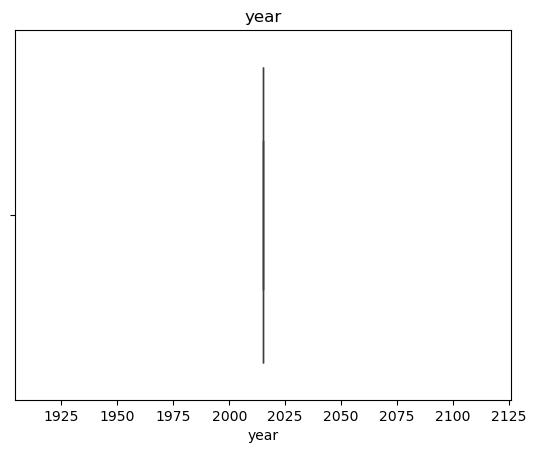

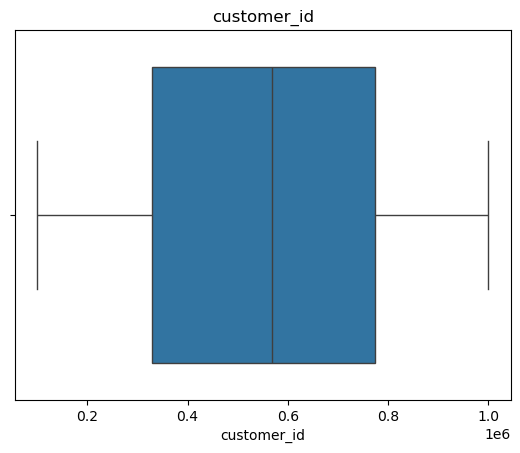

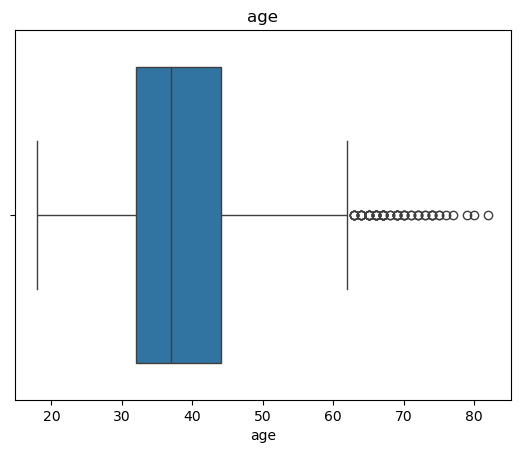

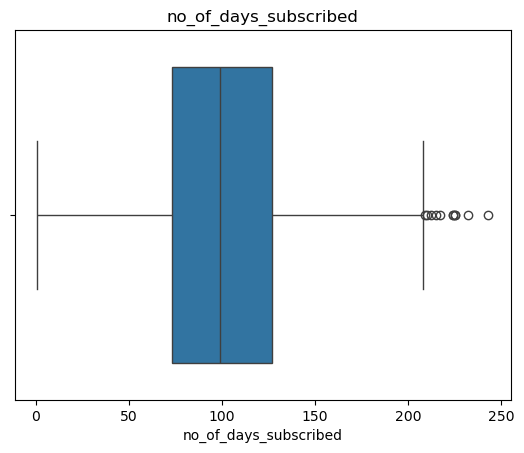

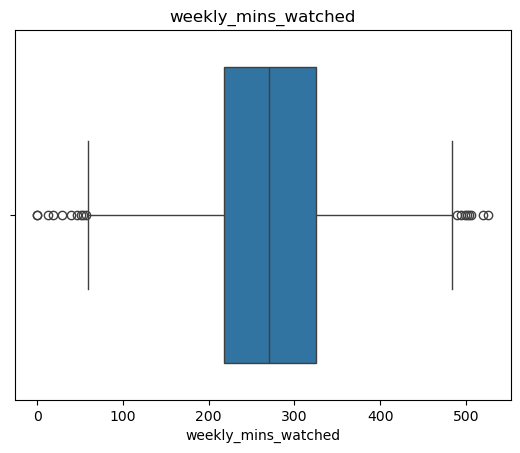

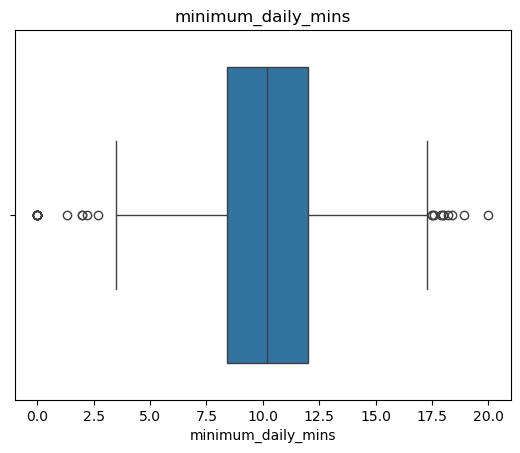

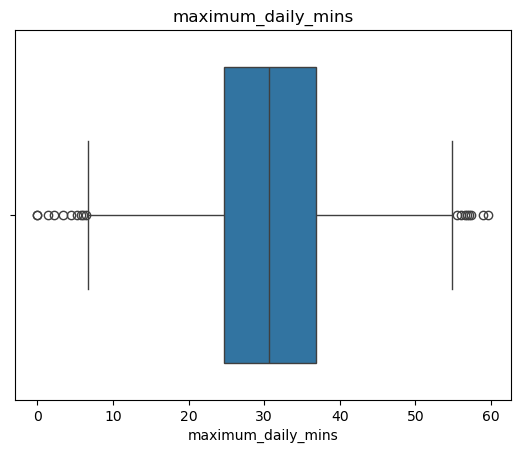

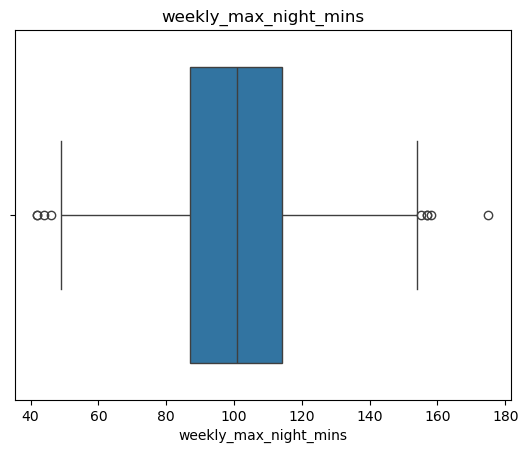

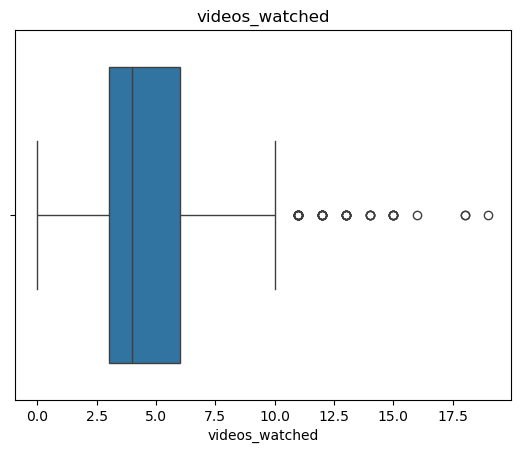

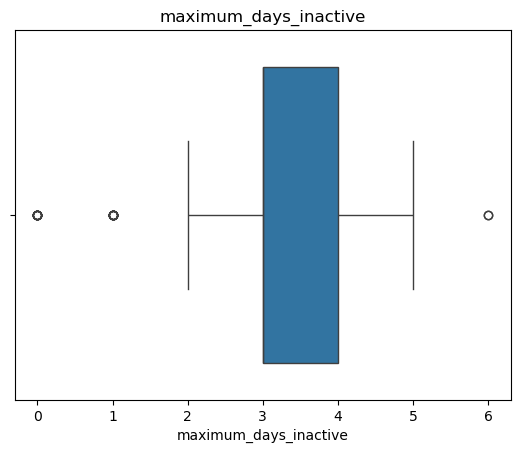

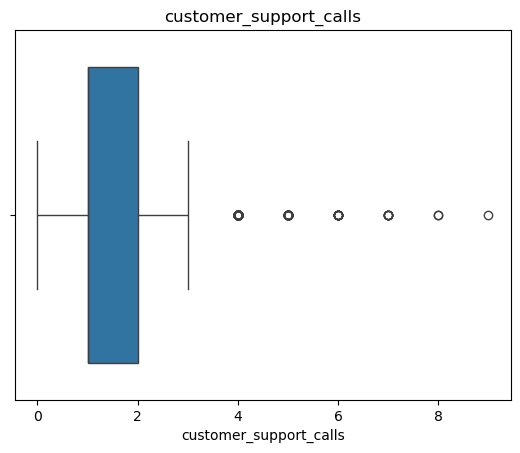

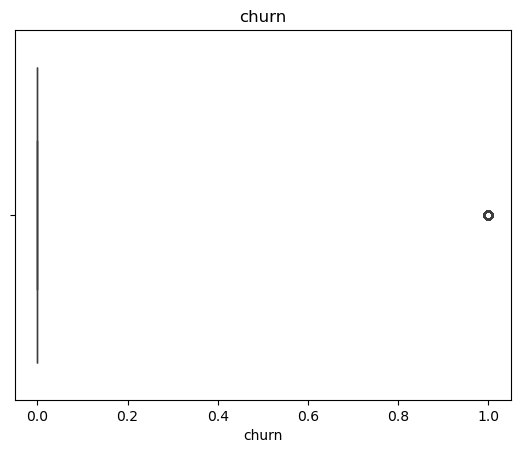

In [27]:
# Numerical Columns – Outlier Check Before Imputation

for col in num_cols:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

**Imputation Strategy**
  
- Outliers present : Median

- No outliers : Mean

- Pattern-based : KNN Imputer

In [31]:
from sklearn.impute import KNNImputer

knn = KNNImputer(n_neighbors=5)

df[num_cols] = knn.fit_transform(df[num_cols])

In [33]:
df[num_cols]

,year,customer_id,age,no_of_days_subscribed,weekly_mins_watched,minimum_daily_mins,maximum_daily_mins,weekly_max_night_mins,videos_watched,maximum_days_inactive,customer_support_calls,churn
0,2015.0,100198.0,36.0,62.0,148.35,12.2,16.81,82.0,1.0,4.0,1.0,0.0
1,2015.0,100643.0,39.0,149.0,294.45,7.7,33.37,87.0,3.0,3.0,2.0,0.0
2,2015.0,100756.0,65.0,126.0,87.30,11.9,9.89,91.0,1.0,4.0,5.0,1.0
3,2015.0,101595.0,24.0,131.0,321.30,9.5,36.41,102.0,4.0,3.0,3.0,0.0
4,2015.0,101653.0,40.0,191.0,243.00,10.9,27.54,83.0,7.0,3.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1995,2015.0,997132.0,54.0,75.0,182.25,11.3,20.66,97.0,5.0,4.0,2.0,0.2
1996,2015.0,998086.0,45.0,127.0,273.45,9.3,30.99,116.0,3.0,3.0,1.0,0.0
1997,2015.0,998474.0,53.0,94.0,128.85,15.6,14.60,110.0,16.0,5.0,0.0,0.0
1998,2015.0,998934.0,40.0,94.0,178.05,10.4,20.18,100.0,6.0,3.6,3.0,0.0


Data Quality Checks
---

In [42]:
df['weekly_mins_watched'] = pd.to_numeric(df['weekly_mins_watched'], errors='coerce')

df['weekly_mins_watched'].isnull().sum()

0

Categorical Column Analysis
--

In [45]:
cat_cols

Index(['phone_no', 'gender', 'multi_screen', 'mail_subscribed'], dtype='object')

Frequency Table
--

In [49]:
for col in cat_cols[1:]:
    print(df[col].value_counts())
    print("-"*40)

gender
Male      1053
Female     923
Name: count, dtype: int64
----------------------------------------
multi_screen
no     1802
yes     198
Name: count, dtype: int64
----------------------------------------
mail_subscribed
no     1430
yes     570
Name: count, dtype: int64
----------------------------------------


Relative Frequency
--

In [52]:
for col in cat_cols[1:]:
    print(df[col].value_counts(normalize=True))
    print("-"*40)

gender
Male      0.532895
Female    0.467105
Name: proportion, dtype: float64
----------------------------------------
multi_screen
no     0.901
yes    0.099
Name: proportion, dtype: float64
----------------------------------------
mail_subscribed
no     0.715
yes    0.285
Name: proportion, dtype: float64
----------------------------------------


Bar Chart
---

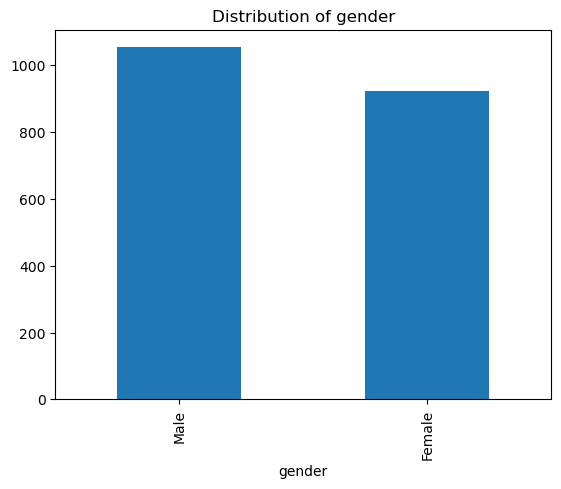

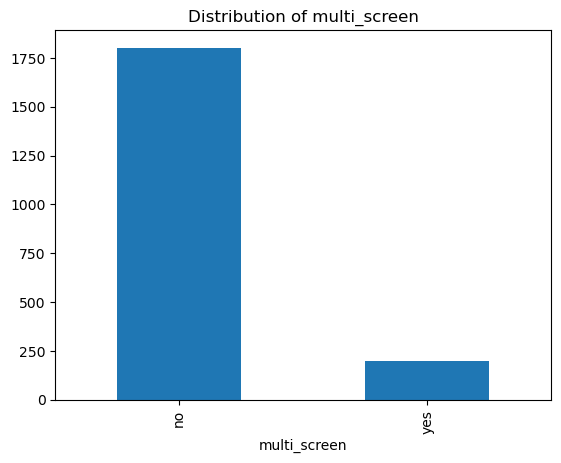

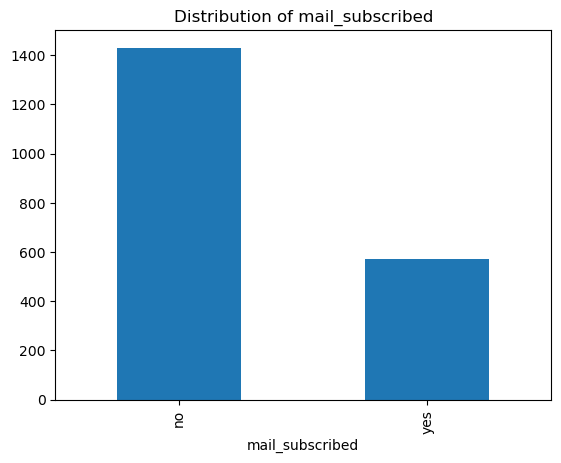

In [58]:
for col in cat_cols[1:]:
    df[col].value_counts().plot(kind='bar')
    plt.title(f'Distribution of {col}')
    plt.show()

Pie Chart
---

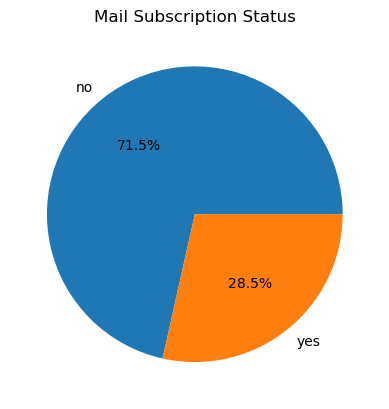

In [61]:
df['mail_subscribed'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.ylabel('')
plt.title('Mail Subscription Status')
plt.show()

Numerical Column Analysis
---

In [64]:
num_cols

Index(['year', 'customer_id', 'age', 'no_of_days_subscribed',
       'weekly_mins_watched', 'minimum_daily_mins', 'maximum_daily_mins',
       'weekly_max_night_mins', 'videos_watched', 'maximum_days_inactive',
       'customer_support_calls', 'churn'],
      dtype='object')

In [66]:
num_cols = ['year','age','no_of_days_subscribed','weekly_mins_watched',
            'minimum_daily_mins','maximum_daily_mins','weekly_max_night_mins',
            'videos_watched','maximum_days_inactive','customer_support_calls','churn']

In [68]:
num_cols

['year',
 'age',
 'no_of_days_subscribed',
 'weekly_mins_watched',
 'minimum_daily_mins',
 'maximum_daily_mins',
 'weekly_max_night_mins',
 'videos_watched',
 'maximum_days_inactive',
 'customer_support_calls',
 'churn']

Statistical Summary
---

In [71]:
df[num_cols].describe()

,year,age,no_of_days_subscribed,weekly_mins_watched,minimum_daily_mins,maximum_daily_mins,weekly_max_night_mins,videos_watched,maximum_days_inactive,customer_support_calls,churn
count,2000.0,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,2015.0,38.69050,99.750000,270.178425,10.198700,30.620780,100.415500,4.482500,3.251800,1.547000,0.133100
std,0.0,10.20641,39.755386,80.551627,2.785519,9.129165,19.529454,2.487728,0.803791,1.315164,0.337344
min,2015.0,18.00000,1.000000,0.000000,0.000000,0.000000,42.000000,0.000000,0.000000,0.000000,0.000000
25%,2015.0,32.00000,73.000000,218.212500,8.400000,24.735000,87.000000,3.000000,3.000000,1.000000,0.000000
50%,2015.0,37.00000,99.000000,269.925000,10.200000,30.590000,101.000000,4.000000,3.000000,1.000000,0.000000
75%,2015.0,44.00000,127.000000,324.675000,12.000000,36.797500,114.000000,6.000000,4.000000,2.000000,0.000000
max,2015.0,82.00000,243.000000,526.200000,20.000000,59.640000,175.000000,19.000000,6.000000,9.000000,1.000000


Histogram & Distribution
---

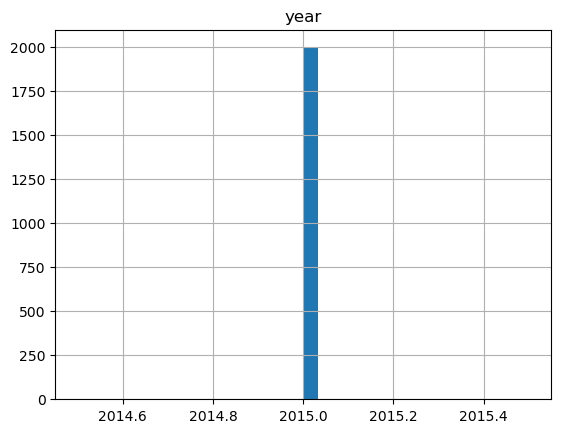

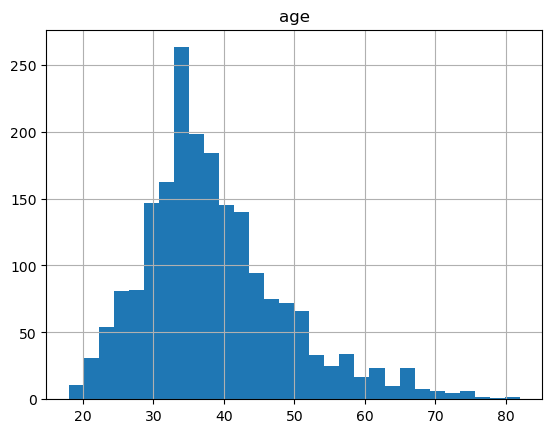

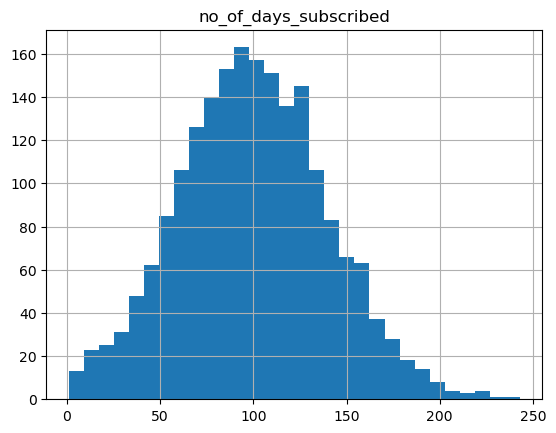

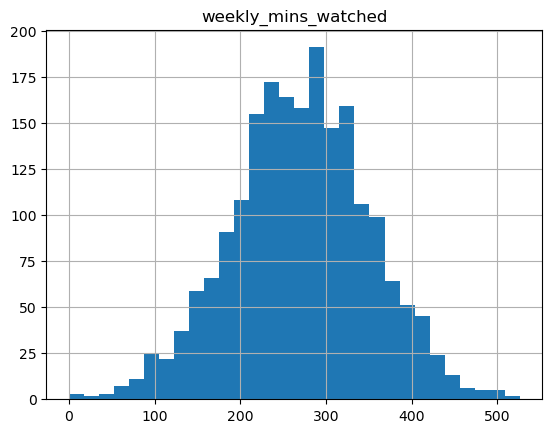

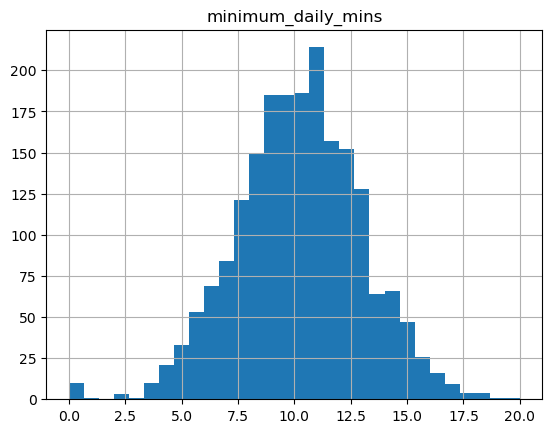

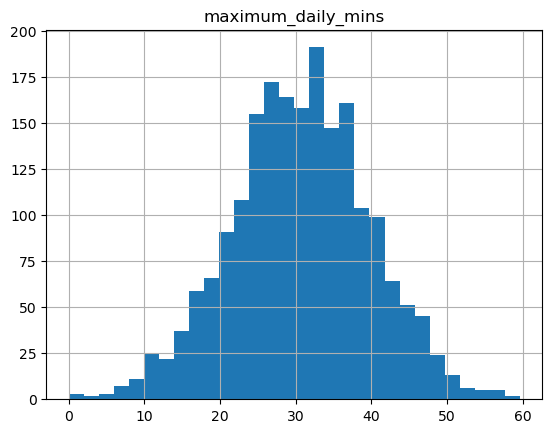

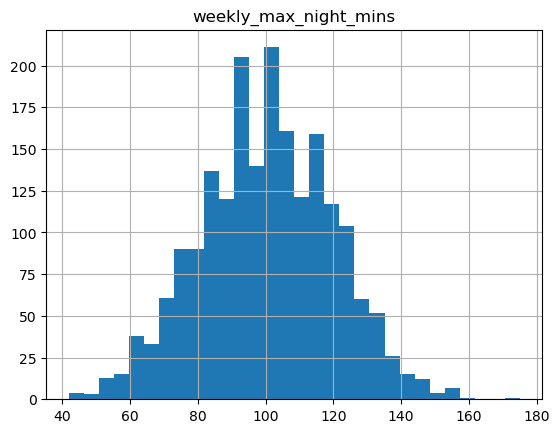

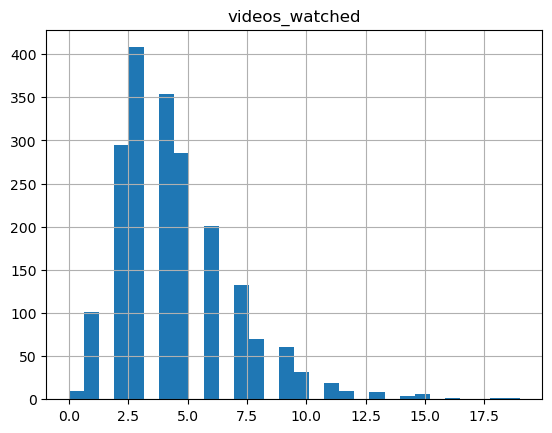

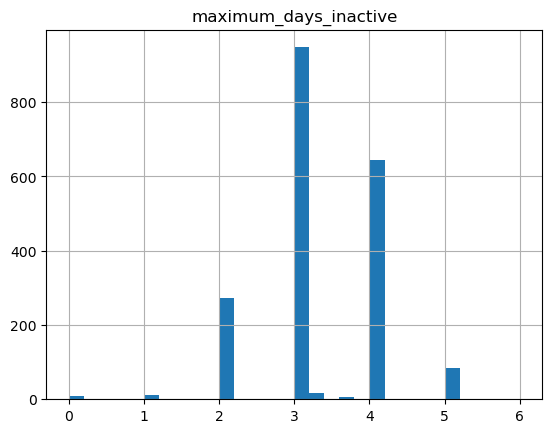

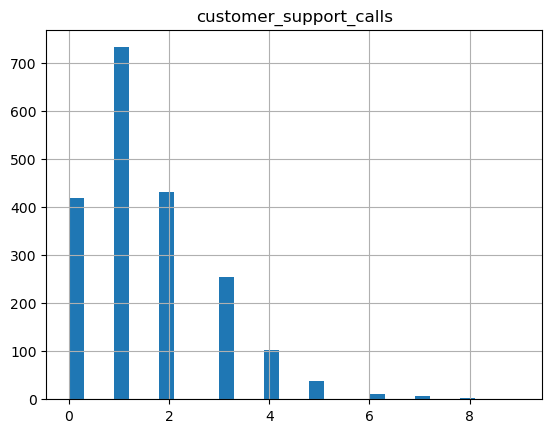

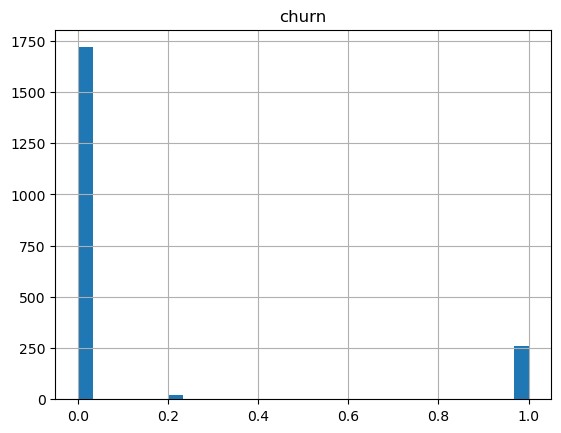

In [74]:
for col in num_cols:
    df[col].hist(bins=30)
    plt.title(col)
    plt.show()

Outlier Analysis
---

Box Plot
--

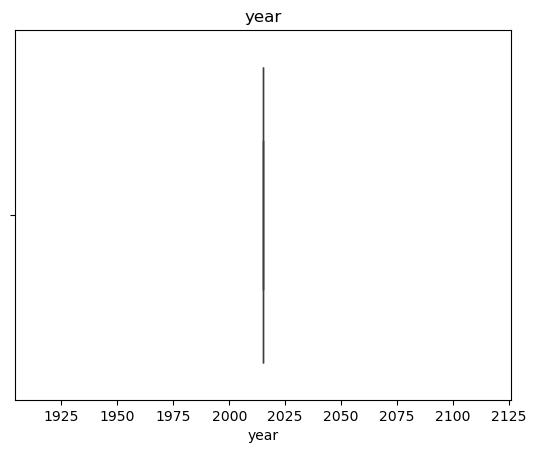

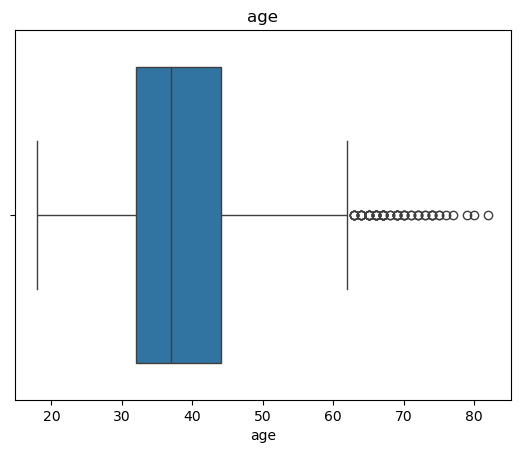

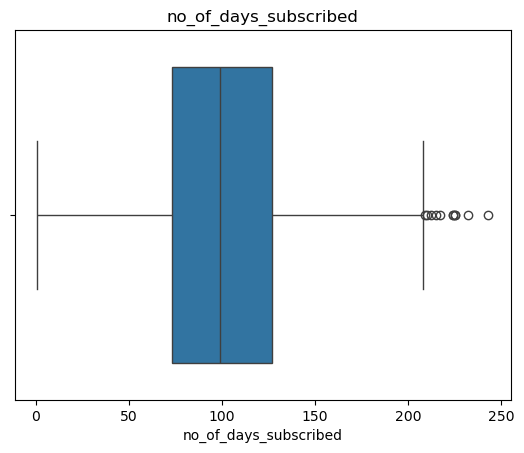

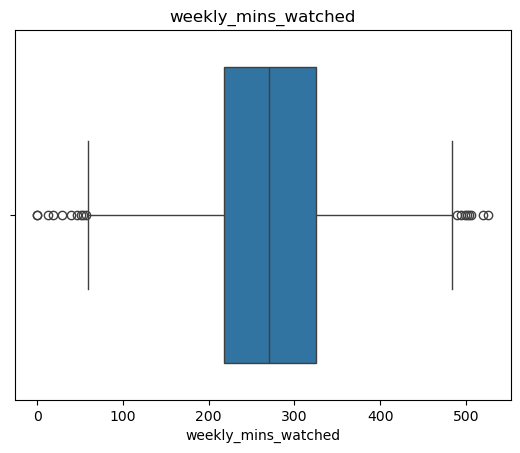

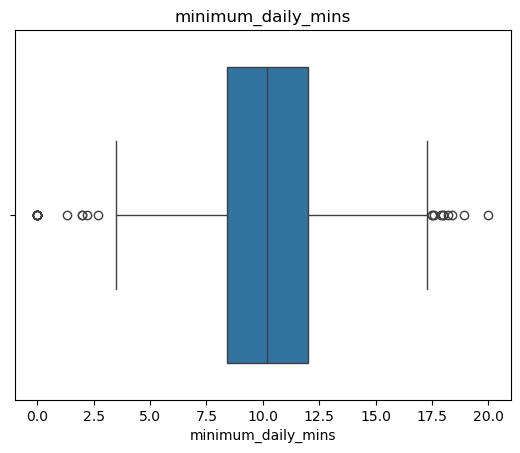

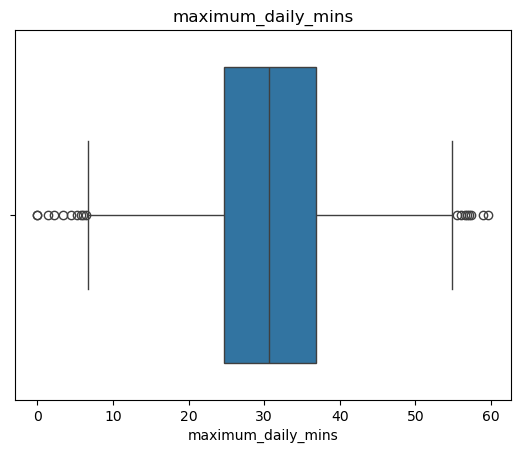

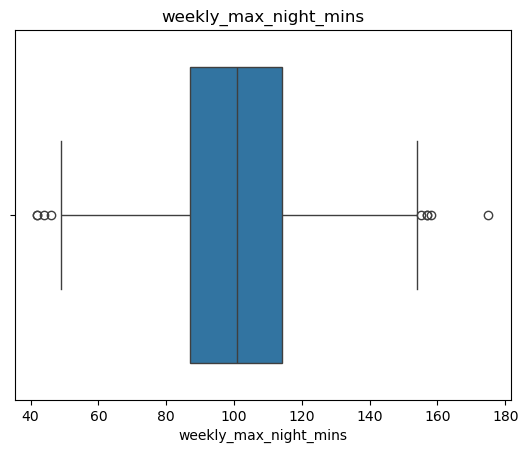

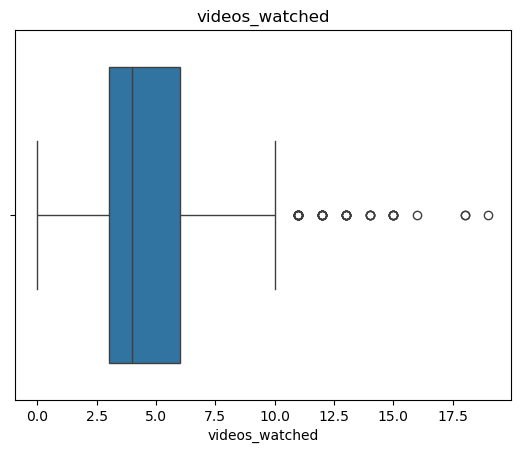

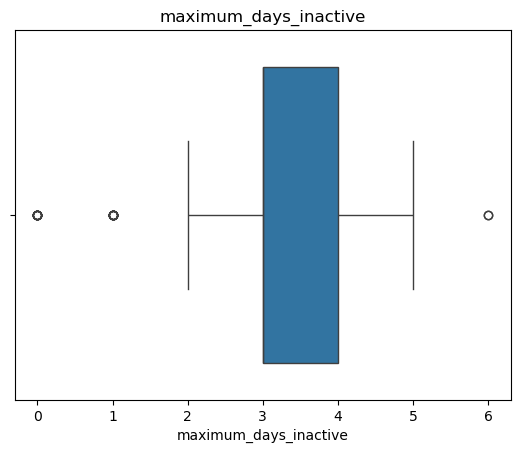

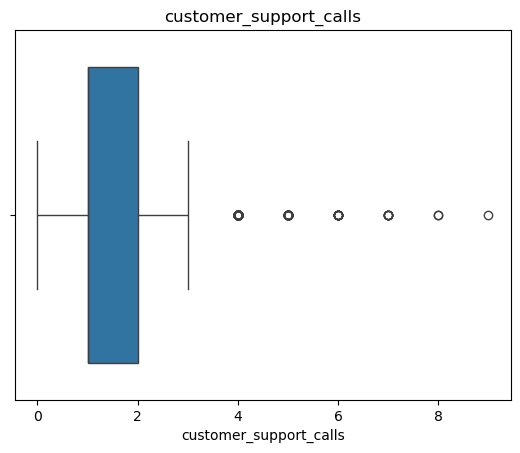

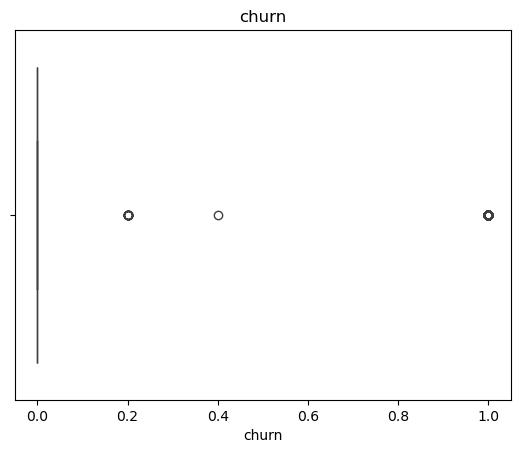

In [78]:
for col in num_cols:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

Outlier Treatment (IQR Method)
---

In [81]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df = df[(df[col] >= Q1 - 1.5*IQR) & (df[col] <= Q3 + 1.5*IQR)]

Bi-Variate & Multi-Variate Analysis
---

Impact of Features on Churn
---

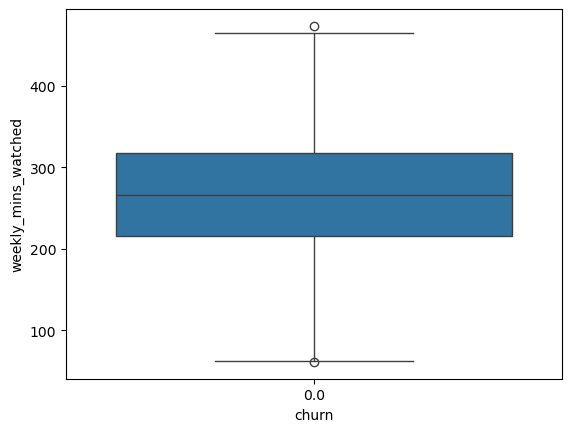

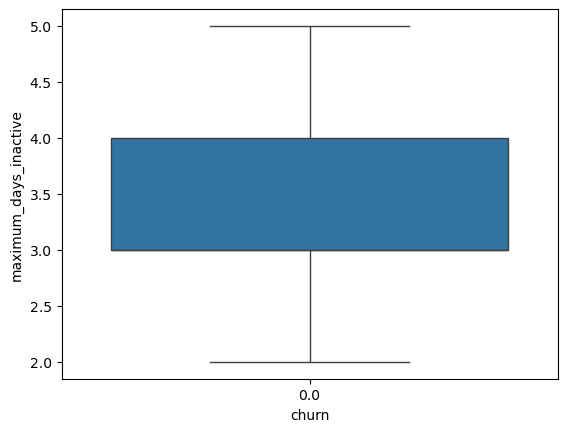

In [85]:
sns.boxplot(x='churn', y='weekly_mins_watched', data=df)
plt.show()

sns.boxplot(x='churn', y='maximum_days_inactive', data=df)
plt.show()

Correlation
---

In [88]:
corr = df[num_cols].corr()

Heatmap
---

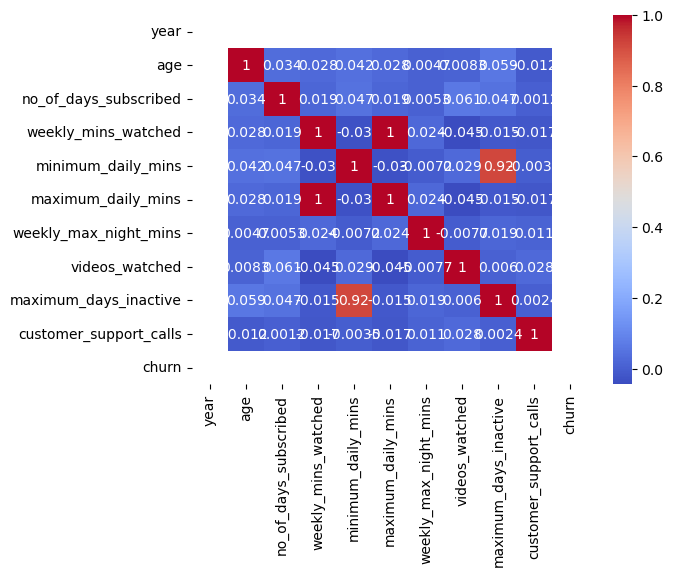

In [91]:
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

Feature Engineering
---

Encoding
--

- **Label Encoding (Binary Categories)**

In [95]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

Scaling
---

Standardization
--

In [101]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])
df[num_cols]

,year,age,no_of_days_subscribed,weekly_mins_watched,minimum_daily_mins,maximum_daily_mins,weekly_max_night_mins,videos_watched,maximum_days_inactive,customer_support_calls,churn
0,0.0,-0.204274,-0.939663,-1.581838,0.765632,-1.582280,-0.962450,-1.596054,0.973071,-0.308218,0.0
1,0.0,0.140008,1.263147,0.404383,-0.987307,0.404194,-0.700991,-0.624825,-0.363075,0.716898,0.0
3,0.0,-1.581400,0.807393,0.769407,-0.286132,0.768861,0.083388,-0.139210,-0.363075,1.742013,0.0
4,0.0,0.254768,2.326573,-0.295077,0.259227,-0.295151,-0.910158,1.317635,-0.363075,-0.308218,0.0
6,0.0,1.861416,-1.015622,-0.346058,-0.013452,-0.345532,0.292556,-0.139210,-0.095846,-1.333334,0.0
...,...,...,...,...,...,...,...,...,...,...,...
1991,0.0,1.287613,-1.243499,2.663862,-0.870445,2.664168,0.449432,-0.624825,-0.363075,-1.333334,0.0
1992,0.0,0.484289,0.503557,-1.196422,-1.026262,-1.196021,-1.276202,-0.624825,-0.363075,1.742013,0.0
1993,0.0,-0.204274,0.706115,0.522659,0.492953,0.522951,0.658599,-0.624825,0.973071,0.716898,0.0
1996,0.0,0.828571,0.706115,0.118889,-0.364040,0.118698,0.815475,-0.624825,-0.363075,-0.308218,0.0


Normalization
--

In [104]:
from sklearn.preprocessing import MinMaxScaler

mm = MinMaxScaler()
df[num_cols] = mm.fit_transform(df[num_cols])
df[num_cols]

,year,age,no_of_days_subscribed,weekly_mins_watched,minimum_daily_mins,maximum_daily_mins,weekly_max_night_mins,videos_watched,maximum_days_inactive,customer_support_calls,churn
0,0.0,0.409091,0.299020,0.211139,0.622222,0.211135,0.314286,0.000000,0.666667,0.333333,0.0
1,0.0,0.477273,0.725490,0.565708,0.288889,0.565739,0.361905,0.222222,0.333333,0.666667,0.0
3,0.0,0.136364,0.637255,0.630870,0.422222,0.630835,0.504762,0.333333,0.333333,1.000000,0.0
4,0.0,0.500000,0.931373,0.440845,0.525926,0.440899,0.323810,0.666667,0.333333,0.333333,0.0
6,0.0,0.818182,0.284314,0.431744,0.474074,0.431906,0.542857,0.333333,0.400000,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...
1991,0.0,0.704545,0.240196,0.969057,0.311111,0.969165,0.571429,0.222222,0.333333,0.000000,0.0
1992,0.0,0.545455,0.578431,0.279942,0.281481,0.280086,0.257143,0.222222,0.333333,1.000000,0.0
1993,0.0,0.409091,0.617647,0.586822,0.570370,0.586938,0.609524,0.222222,0.666667,0.666667,0.0
1996,0.0,0.613636,0.617647,0.514743,0.407407,0.514775,0.638095,0.222222,0.333333,0.333333,0.0


Transformation
---

In [107]:
df['weekly_mins_watched_log'] = np.log1p(df['weekly_mins_watched'])

df['weekly_mins_watched_log'] 

0       0.191562
1       0.448338
3       0.489114
4       0.365229
6       0.358893
          ...   
1991    0.677555
1992    0.246815
1993    0.461733
1996    0.415246
1998    0.249371
Name: weekly_mins_watched_log, Length: 1500, dtype: float64

Conclusion
---

- A comprehensive exploratory data analysis was conducted to understand customer behavior and churn patterns. 

- Columns were analyzed based on their actual meaning, and unnecessary identifier variables were removed. 

- Data cleaning, outlier treatment, and appropriate handling of categorical and numerical variables ensured data quality and consistency. 

- Feature engineering techniques such as encoding, scaling, and transformation were applied to prepare the dataset for modeling. 

- Overall, the dataset is clean, well-structured, and ready for churn prediction and further analysis.